# EDA & Prepocessing Data

## 1. Load Library & Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

In [2]:
df_trx = pd.read_csv('/Users/anargyaisadhimaheswara/Documents/DBS Coding Camp/CAPSTONE/DATA-SCIENCE/data-ds/data_transaksi.csv')
df_nas = pd.read_csv('/Users/anargyaisadhimaheswara/Documents/DBS Coding Camp/CAPSTONE/DATA-SCIENCE/data-ds/data_nasabah.csv')

print('data_transaksi:', df_trx.shape)
print('data_nasabah  :', df_nas.shape)

data_transaksi: (53146, 23)
data_nasabah  : (500, 11)


## 2. Fitur & Tipe Data

In [3]:
print('=== data_transaksi ===')
df_trx.info()

=== data_transaksi ===
<class 'pandas.DataFrame'>
RangeIndex: 53146 entries, 0 to 53145
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_transaksi        53146 non-null  str    
 1   id_user             53146 non-null  str    
 2   timestamp           53146 non-null  str    
 3   tipe_mutasi         53146 non-null  str    
 4   deskripsi_mutasi    53146 non-null  str    
 5   catatan_mutasi      53146 non-null  str    
 6   mcc                 53146 non-null  int64  
 7   nominal             53146 non-null  float64
 8   sisa_saldo          53146 non-null  float64
 9   gt_kategori_besar   53146 non-null  str    
 10  gt_kategori_detail  53146 non-null  str    
 11  label_anomali       53146 non-null  int64  
 12  bulan               53146 non-null  int64  
 13  hari_minggu         53146 non-null  int64  
 14  jam                 53146 non-null  int64  
 15  menit               53146 non-null  int64

In [4]:
print('=== data_nasabah ===')
df_nas.info()

=== data_nasabah ===
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id_user           500 non-null    str  
 1   nama_nasabah      500 non-null    str  
 2   tanggal_lahir     500 non-null    str  
 3   nama_ibu_kandung  500 non-null    str  
 4   segmen_demografi  500 non-null    str  
 5   gaji_bulanan      500 non-null    int64
 6   persona_dasar     500 non-null    str  
 7   is_dynamic        500 non-null    int64
 8   persona_bulan_1   500 non-null    str  
 9   persona_bulan_2   500 non-null    str  
 10  persona_bulan_3   500 non-null    str  
dtypes: int64(2), str(9)
memory usage: 93.7 KB


In [5]:
df_trx.head(3)

,id_transaksi,id_user,timestamp,tipe_mutasi,deskripsi_mutasi,catatan_mutasi,mcc,nominal,sisa_saldo,gt_kategori_besar,...,hari_minggu,jam,menit,hari_bulan,hour_sin,hour_cos,month_sin,month_cos,kategori_detail,kategori_besar
0,TRX-10139,USR-001,2026-01-01 07:00:00,Kredit,TRF MASUK - PENDAPATAN TETAP,-,0,3130000.0,3130000.0,Pemasukan,...,3,7,0,1,0.965926,-0.258819,0.0,1.0,Pendapatan Bulanan,Income
1,TRX-10140,USR-001,2026-01-01 09:00:00,Debit,NETFLIX,Auto-Debit Monthly,4899,186000.0,2944000.0,Wants,...,3,9,0,1,0.707107,-0.707107,0.0,1.0,Hiburan & Langganan,Wants
2,TRX-10141,USR-001,2026-01-01 09:00:00,Debit,BPJS KESEHATAN,Auto-Debit Monthly,8099,150000.0,2794000.0,Needs,...,3,9,0,1,0.707107,-0.707107,0.0,1.0,Kesehatan & Perawatan Diri,Needs


In [6]:
df_nas.head(3)

,id_user,nama_nasabah,tanggal_lahir,nama_ibu_kandung,segmen_demografi,gaji_bulanan,persona_dasar,is_dynamic,persona_bulan_1,persona_bulan_2,persona_bulan_3
0,USR-362,Sutan Perkasa Hakim,1992-10-30,Gina Permata,First Jobber,4750000,Unconflicted,0,Unconflicted,Unconflicted,Unconflicted
1,USR-074,"Bakiadi Suryono, M.TI.",2002-04-04,dr. Cornelia Prakasa,Mahasiswa,3210000,Unconflicted,0,Unconflicted,Unconflicted,Unconflicted
2,USR-375,Karen Mulyani,2006-03-14,Cinthia Halimah,First Jobber,5580000,Tightwad,0,Tightwad,Tightwad,Tightwad


## 3. Missing Values & Duplikat

In [7]:
print('=== Missing Values - data_transaksi ===')
print(df_trx.isnull().sum()[df_trx.isnull().sum() > 0])
print('\nDuplikat:', df_trx.duplicated().sum())

=== Missing Values - data_transaksi ===
kategori_besar    916
dtype: int64

Duplikat: 0


## 4. Konversi Tipe Data

In [9]:
df_trx['timestamp'] = pd.to_datetime(df_trx['timestamp'])
df_nas['tanggal_lahir'] = pd.to_datetime(df_nas['tanggal_lahir'])
print('timestamp dtype    :', df_trx['timestamp'].dtype)
print('tanggal_lahir dtype:', df_nas['tanggal_lahir'].dtype)

timestamp dtype    : datetime64[us]
tanggal_lahir dtype: datetime64[us]


## 5. Statistik Deskriptif

In [10]:
df_trx[['nominal', 'sisa_saldo']].describe().round(0)

,nominal,sisa_saldo
count,53146.0,53146.0
mean,348423.0,3508601.0
std,1296624.0,4150168.0
min,0.0,5002.0
25%,39477.0,594134.0
50%,78114.0,1984141.0
75%,186000.0,4644000.0
max,19290000.0,21403371.0


In [11]:
df_nas[['gaji_bulanan']].describe().round(0)

,gaji_bulanan
count,500.0
mean,5944160.0
std,4555535.0
min,1500000.0
25%,2870000.0
50%,4960000.0
75%,5750000.0
max,19980000.0


## 6. Sebaran Data - Kategorikal (Transaksi)

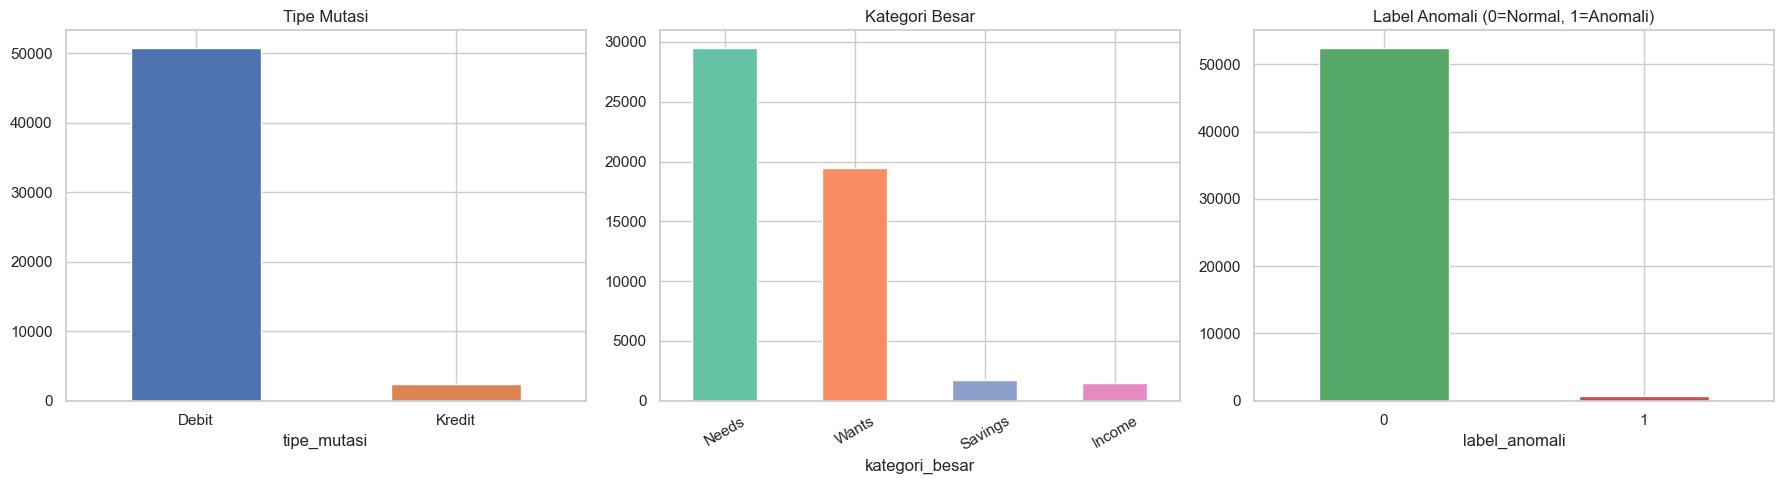

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_trx['tipe_mutasi'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'])
axes[0].set_title('Tipe Mutasi')
axes[0].tick_params(axis='x', rotation=0)

df_trx['kategori_besar'].value_counts().plot(kind='bar', ax=axes[1], color=sns.color_palette('Set2'))
axes[1].set_title('Kategori Besar')
axes[1].tick_params(axis='x', rotation=30)

df_trx['label_anomali'].value_counts().plot(kind='bar', ax=axes[2], color=['#55A868','#C44E52'])
axes[2].set_title('Label Anomali (0=Normal, 1=Anomali)')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 7. Sebaran Data - Kategorikal (Nasabah)

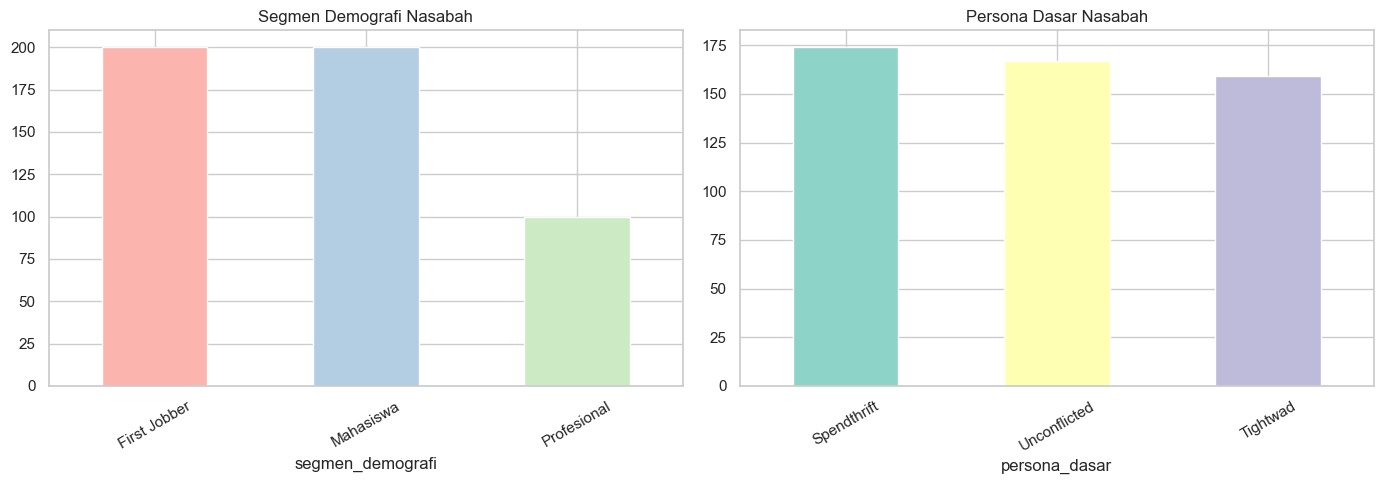

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_nas['segmen_demografi'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette('Pastel1'))
axes[0].set_title('Segmen Demografi Nasabah')
axes[0].tick_params(axis='x', rotation=30)

df_nas['persona_dasar'].value_counts().plot(kind='bar', ax=axes[1], color=sns.color_palette('Set3'))
axes[1].set_title('Persona Dasar Nasabah')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 8. Sebaran Data - Numerik

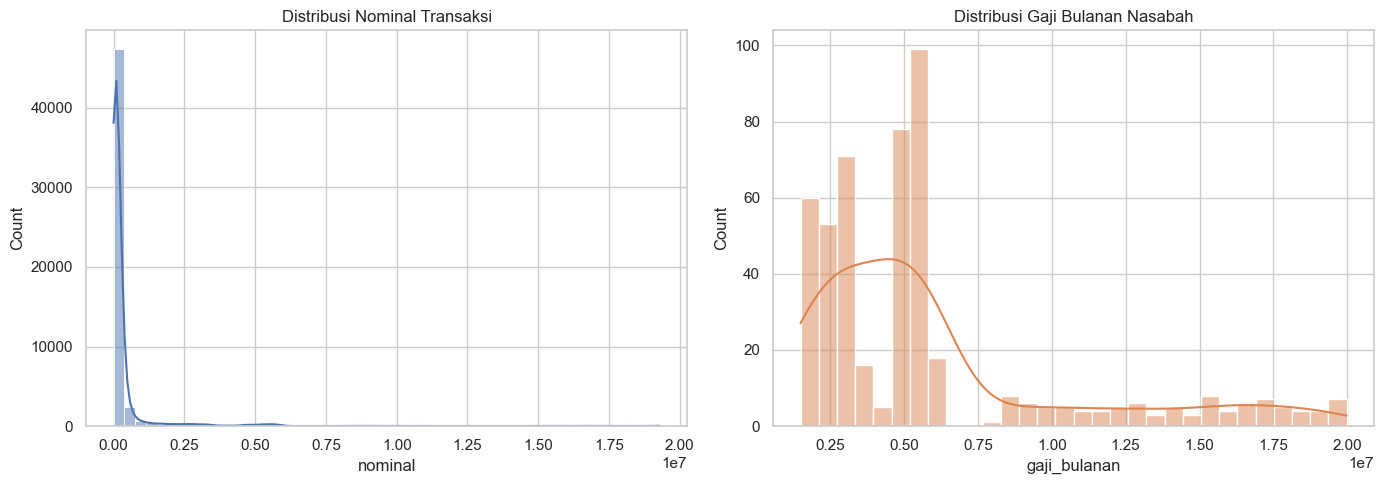

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_trx['nominal'], bins=50, ax=axes[0], kde=True, color='#4C72B0')
axes[0].set_title('Distribusi Nominal Transaksi')

sns.histplot(df_nas['gaji_bulanan'], bins=30, ax=axes[1], kde=True, color='#DD8452')
axes[1].set_title('Distribusi Gaji Bulanan Nasabah')

plt.tight_layout()
plt.show()

## 9. Sebaran Transaksi per Waktu

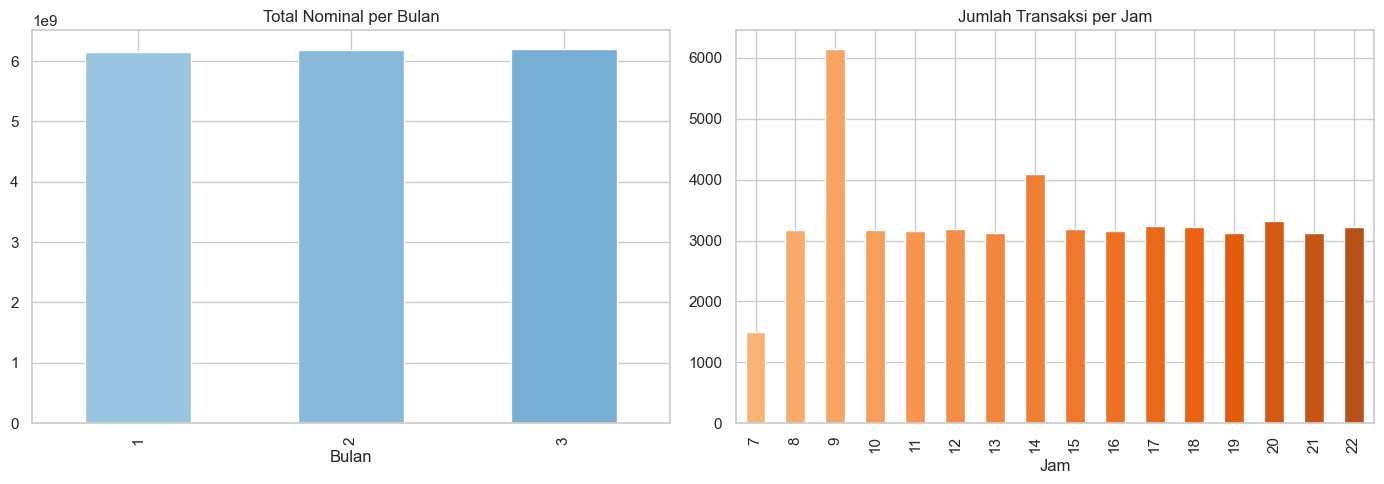

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_trx.groupby('bulan')['nominal'].sum().plot(kind='bar', ax=axes[0], color=sns.color_palette('Blues_d', 12))
axes[0].set_title('Total Nominal per Bulan')
axes[0].set_xlabel('Bulan')

df_trx.groupby('jam')['id_transaksi'].count().plot(kind='bar', ax=axes[1], color=sns.color_palette('Oranges_d', 24))
axes[1].set_title('Jumlah Transaksi per Jam')
axes[1].set_xlabel('Jam')

plt.tight_layout()
plt.show()

## 10. Top Kategori Detail Transaksi

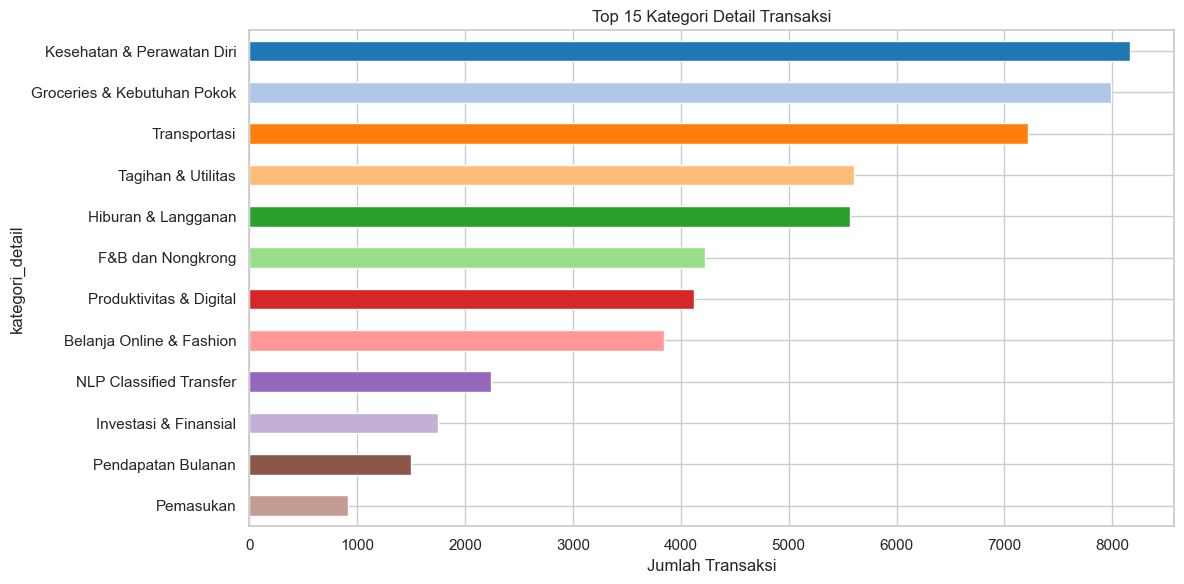

In [16]:
top_kategori = df_trx['kategori_detail'].value_counts().head(15)
top_kategori.plot(kind='barh', figsize=(12, 6), color=sns.color_palette('tab20', 15))
plt.title('Top 15 Kategori Detail Transaksi')
plt.xlabel('Jumlah Transaksi')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()